# No-Optimization CG-Projection Enclosure for the system_303 problem

This notebook uses the same data files and initial box as `system_303_solver_v2.ipynb`. The first three boundary-condition rows/columns are removed so the system dimension matches v2's `box[3:]` initial interval.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from matplotlib.animation import FuncAnimation
from scipy.linalg import qr, solve
from scipy.sparse.linalg import cg

base_dir = Path("system_303")

A_full = np.genfromtxt(base_dir / "stiffness_beam_A.dat", delimiter=",")
b_full = np.genfromtxt(base_dir / "forcing_b.dat")
box = np.genfromtxt(base_dir / "B0_wide_bc.dat", delimiter=",")
x_star_full = np.genfromtxt(base_dir / "soln_x.dat")

# Match the 300-dimensional free-coordinate box used in v2.
A = A_full[3:, 3:]
b = b_full[3:]
x_star = x_star_full[3:]
ell0 = box[3:, 0]
u0 = box[3:, 1]

print("A shape:", A.shape)
print("b shape:", b.shape)
print("initial box shape:", ell0.shape)
print("x_star shape:", x_star.shape)


A shape: (300, 300)
b shape: (300,)
initial box shape: (300,)
x_star shape: (300,)


## Preconditioning

As in v2, use symmetric Jacobi scaling. With `scale = sqrt(diag(A))`, the preconditioned variables are `y = scale * x`,

$$
\hat A = D^{-1/2} A D^{-1/2}, \qquad \hat b = D^{-1/2} b.
$$

The initial interval is transformed to `[scale * ell0, scale * u0]`, and the final contracted interval is transformed back by dividing by `scale`.


In [3]:
diag_A = np.diag(A)
if np.any(diag_A <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diag_A)
A_hat = A / scale[:, None] / scale[None, :]
b_hat = b / scale

ell_hat = scale * ell0
u_hat = scale * u0
c0 = 0.5 * (ell_hat + u_hat)
d0 = 0.5 * (u_hat - ell_hat)

# Diagnostics, matching the style of v2.
eigvals_A = np.linalg.eigvalsh(A)
eigvals_A_hat = np.linalg.eigvalsh(A_hat)

print("A:")
print(f"  smallest eigenvalue: {eigvals_A[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A[-1]:.16e}")
print(f"  condition number:    {eigvals_A[-1] / eigvals_A[0]:.16e}")

print("\nA_hat:")
print(f"  smallest eigenvalue: {eigvals_A_hat[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A_hat[-1]:.16e}")
print(f"  condition number:    {eigvals_A_hat[-1] / eigvals_A_hat[0]:.16e}")


A:
  smallest eigenvalue: 7.0008220394031389e+02
  biggest eigenvalue:  3.2879900893790034e+12
  condition number:    4.6965771603291941e+09

A_hat:
  smallest eigenvalue: 2.9392884118717852e-08
  biggest eigenvalue:  2.6861406616345080e+00
  condition number:    9.1387447750455067e+07


## SciPy CG baseline

This is only a baseline residual trace. The projection enclosure below uses the fixed-iteration custom CG implementation so the search directions are available.


SciPy CG info: 500 (0 means converged)
SciPy CG iterations recorded: 500
SciPy CG final residual norm: 1.3409854228882576


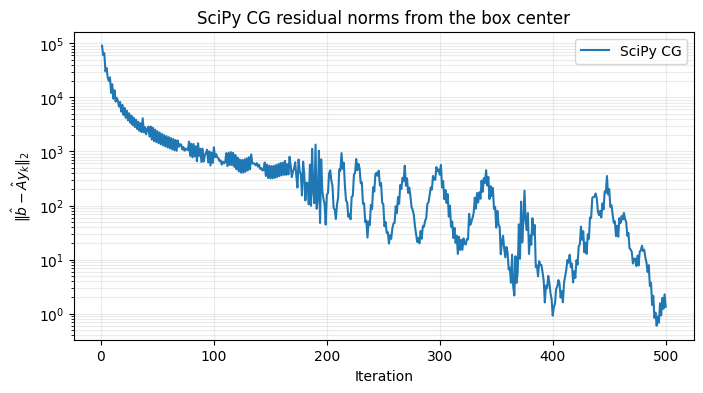

In [4]:
n = len(b_hat)
max_iter = 500
cg_projection_iterations = max_iter
_cg_rtol = 1e-10
_cg_atol = 0.0

scipy_residual_norms = []


def record_scipy_residual(xk):
    scipy_residual_norms.append(np.linalg.norm(b_hat - A_hat @ xk))


x_scipy_cg, scipy_cg_info = cg(
    A_hat,
    b_hat,
    x0=c0,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=max_iter,
    callback=record_scipy_residual,
)

print("SciPy CG info:", scipy_cg_info, "(0 means converged)")
print("SciPy CG iterations recorded:", len(scipy_residual_norms))
if scipy_residual_norms:
    print("SciPy CG final residual norm:", scipy_residual_norms[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(
    range(1, len(scipy_residual_norms) + 1),
    scipy_residual_norms,
    label="SciPy CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\hat b - \hat A y_k\|_2$")
ax.set_title("SciPy CG residual norms from the box center")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Custom fixed-iteration CG with recorded directions

This follows the unpreconditioned SciPy CG recurrence on the already preconditioned matrix `A_hat`. The start point is the initial box center, as required by the projection-enclosure algorithm.


Custom fixed CG iterations: 500
Custom CG final residual norm: 1.3409854230165235
P_all shape: (300, 500)
AP_all shape: (300, 500)


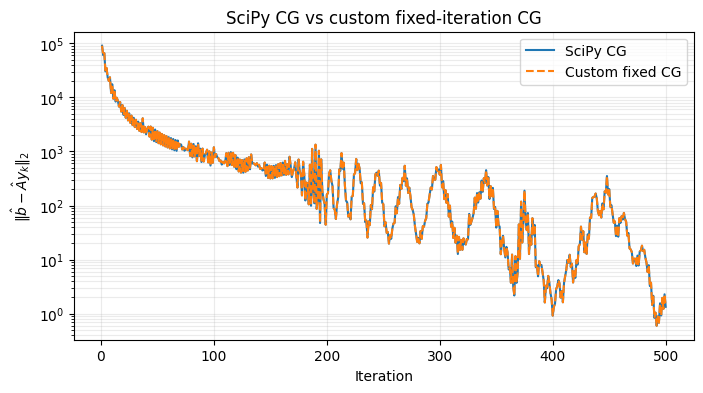

In [5]:
def cg_fixed_iterations_with_directions(A, b, x0, m):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.array(x0, dtype=float, copy=True)

    r = b - A @ x
    p = r.copy()

    residual_norms = []
    p_list = []
    ap_list = []
    alpha_list = []
    beta_list = []

    for k in range(m):
        Ap = A @ p
        rr = float(r @ r)
        denom = float(p @ Ap)
        if denom <= 0 or not np.isfinite(denom):
            raise RuntimeError(f"CG denominator is not positive and finite at iteration {k}.")

        alpha = rr / denom
        x = x + alpha * p
        r_next = r - alpha * Ap

        p_list.append(p.copy())
        ap_list.append(Ap.copy())
        alpha_list.append(alpha)
        residual_norms.append(np.linalg.norm(r_next))

        if k < m - 1:
            rr_next = float(r_next @ r_next)
            if rr == 0:
                beta = 0.0
            else:
                beta = rr_next / rr
            p = r_next + beta * p
            beta_list.append(beta)

        r = r_next

    return {
        "x": x,
        "r": r,
        "P_all": np.column_stack(p_list),
        "AP_all": np.column_stack(ap_list),
        "alpha": np.array(alpha_list),
        "beta": np.array(beta_list),
        "residual_norms": np.array(residual_norms),
    }


cg_run = cg_fixed_iterations_with_directions(
    A=A_hat,
    b=b_hat,
    x0=c0,
    m=max_iter,
)

x_custom_cg = cg_run["x"]
custom_residual_norms = cg_run["residual_norms"]
P_all = cg_run["P_all"]
AP_all = cg_run["AP_all"]

print("Custom fixed CG iterations:", max_iter)
print("Custom CG final residual norm:", custom_residual_norms[-1])
print("P_all shape:", P_all.shape)
print("AP_all shape:", AP_all.shape)

fig, ax = plt.subplots(figsize=(8, 4))
if scipy_residual_norms:
    ax.semilogy(
        range(1, len(scipy_residual_norms) + 1),
        scipy_residual_norms,
        label="SciPy CG",
    )
ax.semilogy(
    range(1, len(custom_residual_norms) + 1),
    custom_residual_norms,
    "--",
    label="Custom fixed CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\hat b - \hat A y_k\|_2$")
ax.set_title("SciPy CG vs custom fixed-iteration CG")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Projection enclosure contraction

The selector below A-normalizes each recorded CG direction locally before building the projected Gram matrix. This makes the condition-number check measure loss of A-conjugacy rather than arbitrary search-direction scaling. The raw-direction selector is kept under `direction_scaling="raw"` for comparison on the same stored CG trajectory.


In [6]:
def _left_project_A(P, A):
    """Return P.T @ A without requiring dense conversion when A is sparse."""
    if hasattr(A, "T") and not isinstance(A, np.ndarray):
        return (A.T @ P).T
    return P.T @ A


def _qr_rank_from_columns(P, qr_tol=1e-10):
    column_norms = np.linalg.norm(P, axis=0)
    nonzero = np.isfinite(column_norms) & (column_norms > 0)
    if not np.any(nonzero):
        return 0

    P_unit = P[:, nonzero] / column_norms[nonzero][None, :]
    _, R, _ = qr(P_unit, pivoting=True, mode="economic")
    diag_R = np.abs(np.diag(R))
    if diag_R.size == 0 or diag_R[0] == 0:
        return 0
    return int(np.sum(diag_R > qr_tol * diag_R[0]))


def _gram_diagnostics(G):
    identity_error = G - np.eye(G.shape[0])
    if G.shape[0] <= 1:
        max_offdiag = 0.0
    else:
        offdiag = identity_error - np.diag(np.diag(identity_error))
        max_offdiag = float(np.max(np.abs(offdiag)))

    return {
        "g_identity_fro": float(np.linalg.norm(identity_error, ord="fro")),
        "g_identity_inf": float(np.linalg.norm(identity_error, ord=np.inf)),
        "g_max_offdiag_abs": max_offdiag,
        "g_symmetry_error": float(np.linalg.norm(G - G.T, ord=np.inf)),
        "g_diag_max_abs_error": float(np.max(np.abs(np.diag(G) - 1.0))) if G.size else np.nan,
    }


def select_independent_directions_a_normalized(P_all, A, qr_tol=1e-10, max_g_condition=1e12):
    P_all = np.asarray(P_all, dtype=float)
    AP_all = np.asarray(A @ P_all, dtype=float)

    a_norm_sq = np.sum(P_all * AP_all, axis=0)
    valid = np.isfinite(a_norm_sq) & (a_norm_sq > 0)
    valid_direction_count = int(np.sum(valid))
    if valid_direction_count == 0:
        raise RuntimeError("No valid positive-A-norm CG directions.")

    original_indices = np.flatnonzero(valid)
    a_norms = np.sqrt(a_norm_sq[valid])
    Q_all = P_all[:, valid] / a_norms[None, :]
    AQ_all = AP_all[:, valid] / a_norms[None, :]

    _, R, piv = qr(Q_all, pivoting=True, mode="economic")
    diag_R = np.abs(np.diag(R))
    if diag_R.size == 0 or diag_R[0] == 0:
        raise RuntimeError("Could not determine the direction rank.")

    qr_rank = int(np.sum(diag_R > qr_tol * diag_R[0]))
    qr_rank = max(qr_rank, 1)
    raw_qr_rank = _qr_rank_from_columns(P_all[:, valid], qr_tol=qr_tol)

    last_condition = np.inf
    last_rank = None
    for rank in range(qr_rank, 0, -1):
        local_selected = piv[:rank]
        P = Q_all[:, local_selected]
        AP = AQ_all[:, local_selected]
        G = P.T @ AP
        condition = np.linalg.cond(G)
        last_condition = condition
        last_rank = rank

        if np.isfinite(condition) and condition <= max_g_condition:
            selected = original_indices[local_selected]
            result = {
                "method": "a_normalized",
                "selected": selected,
                "P": P,
                "AP": AP,
                "G": G,
                "condition": float(condition),
                "g_condition": float(condition),
                "qr_rank": qr_rank,
                "retained_rank": rank,
                "valid_direction_count": valid_direction_count,
                "available_direction_count": int(P_all.shape[1]),
                "raw_qr_rank": raw_qr_rank,
                "a_norms_all_valid": a_norms,
                "a_norm_sq_all": a_norm_sq,
            }
            result.update(_gram_diagnostics(G))
            return result

    raise RuntimeError(
        "Unable to obtain a numerically stable A-normalized direction set; "
        f"last retained-rank attempt was {last_rank}, with cond(G)={last_condition:.3e}."
    )


def select_independent_directions_raw(P_all, A, qr_tol=1e-10, max_g_condition=1e12):
    P_all = np.asarray(P_all, dtype=float)
    AP_all = np.asarray(A @ P_all, dtype=float)

    a_norm_sq = np.sum(P_all * AP_all, axis=0)
    valid = np.isfinite(a_norm_sq) & (a_norm_sq > 0)
    valid_direction_count = int(np.sum(valid))

    column_norms = np.linalg.norm(P_all, axis=0)
    nonzero = np.isfinite(column_norms) & (column_norms > 0)
    if not np.any(nonzero):
        raise RuntimeError("No nonzero CG directions were generated.")

    original_indices = np.flatnonzero(nonzero)
    P_unit = P_all[:, nonzero] / column_norms[nonzero][None, :]

    _, R, piv = qr(P_unit, pivoting=True, mode="economic")
    diag_R = np.abs(np.diag(R))
    if diag_R.size == 0 or diag_R[0] == 0:
        raise RuntimeError("Could not determine a nonzero direction rank.")

    qr_rank = int(np.sum(diag_R > qr_tol * diag_R[0]))
    qr_rank = max(1, qr_rank)

    last_condition = np.inf
    last_rank = None
    for rank in range(qr_rank, 0, -1):
        selected = np.sort(original_indices[piv[:rank]])
        P = P_all[:, selected]
        AP = AP_all[:, selected]
        G = P.T @ AP
        condition = np.linalg.cond(G)
        last_condition = condition
        last_rank = rank

        if np.isfinite(condition) and condition <= max_g_condition:
            result = {
                "method": "raw",
                "selected": selected,
                "P": P,
                "AP": AP,
                "G": G,
                "condition": float(condition),
                "g_condition": float(condition),
                "qr_rank": qr_rank,
                "retained_rank": rank,
                "valid_direction_count": valid_direction_count,
                "available_direction_count": int(P_all.shape[1]),
                "raw_qr_rank": qr_rank,
                "a_norms_all_valid": np.sqrt(a_norm_sq[valid]) if valid_direction_count else np.array([]),
                "a_norm_sq_all": a_norm_sq,
            }
            result.update(_gram_diagnostics(G))
            return result

    raise RuntimeError(
        "Unable to select a numerically stable raw direction set; "
        f"last retained-rank attempt was {last_rank}, with cond(G)={last_condition:.3e}."
    )


def select_independent_directions(
    P_all,
    A,
    qr_tol=1e-10,
    max_g_condition=1e12,
    direction_scaling="a_normalized",
):
    if direction_scaling == "a_normalized":
        return select_independent_directions_a_normalized(
            P_all=P_all,
            A=A,
            qr_tol=qr_tol,
            max_g_condition=max_g_condition,
        )
    if direction_scaling == "raw":
        return select_independent_directions_raw(
            P_all=P_all,
            A=A,
            qr_tol=qr_tol,
            max_g_condition=max_g_condition,
        )
    raise ValueError('direction_scaling must be "raw" or "a_normalized".')


def contract_interval_projection(
    A,
    b,
    ell,
    u,
    P_all,
    tau=0.0,
    qr_tol=1e-10,
    max_g_condition=1e12,
    direction_scaling="a_normalized",
):
    ell = np.asarray(ell, dtype=float)
    u = np.asarray(u, dtype=float)
    c = 0.5 * (ell + u)
    d = 0.5 * (u - ell)

    selection = select_independent_directions(
        P_all=P_all,
        A=A,
        qr_tol=qr_tol,
        max_g_condition=max_g_condition,
        direction_scaling=direction_scaling,
    )

    P = selection["P"]
    AP = selection["AP"]
    G = selection["G"]
    retained_rank = selection["retained_rank"]

    ap_norms = np.linalg.norm(AP, axis=0)
    if np.any(~np.isfinite(ap_norms)) or np.any(ap_norms == 0):
        raise RuntimeError("Selected direction has a zero or nonfinite A*p norm.")

    rhs = P.T @ (b - A @ c)
    coeff = solve(G, rhs, assume_a="sym", check_finite=False)
    x_hat = c + P @ coeff

    Ginv_PTA = solve(
        G,
        _left_project_A(P, A),
        assume_a="sym",
        check_finite=False,
    )
    Pi = np.eye(len(b)) - P @ Ginv_PTA

    PGinv = solve(
        G,
        P.T,
        assume_a="sym",
        check_finite=False,
    ).T

    t = tau * ap_norms
    d_proj = np.abs(Pi) @ d + np.abs(PGinv) @ t

    ell_new = np.maximum(ell, x_hat - d_proj)
    u_new = np.minimum(u, x_hat + d_proj)

    if np.any(ell_new > u_new):
        violation = ell_new - u_new
        bad = np.flatnonzero(violation > 0)
        raise RuntimeError(
            "Projection enclosure produced inverted intervals; "
            f"max violation={np.max(violation):.6e}, first coordinates={bad[:10]}."
        )

    a_norm_check = np.sum(P * AP, axis=0)
    constraint_residual = P.T @ (A @ x_hat - b)
    normalized_constraint_violation = float(np.max(np.abs(constraint_residual))) if retained_rank else np.nan

    return {
        "ell": ell_new,
        "u": u_new,
        "x_hat": x_hat,
        "radius": d_proj,
        "selected": selection["selected"],
        "P": P,
        "AP": AP,
        "G": G,
        "Pi": Pi,
        "PGinv": PGinv,
        "t": t,
        "g_condition": selection["g_condition"],
        "condition": selection["condition"],
        "qr_rank": selection["qr_rank"],
        "retained_rank": retained_rank,
        "valid_direction_count": selection["valid_direction_count"],
        "available_direction_count": selection["available_direction_count"],
        "raw_qr_rank": selection["raw_qr_rank"],
        "g_max_offdiag_abs": selection["g_max_offdiag_abs"],
        "g_identity_fro": selection["g_identity_fro"],
        "g_identity_inf": selection["g_identity_inf"],
        "g_symmetry_error": selection["g_symmetry_error"],
        "g_diag_max_abs_error": selection["g_diag_max_abs_error"],
        "a_norm_check": a_norm_check,
        "a_norm_unit_max_error": float(np.max(np.abs(a_norm_check - 1.0))),
        "max_constraint_residual_x_hat": normalized_constraint_violation,
        "direction_scaling": direction_scaling,
    }


def run_periodic_interval_contractions(
    A,
    b,
    ell,
    u,
    P_all,
    max_iter,
    contraction_period,
    tau=0.0,
    qr_tol=1e-10,
    max_g_condition=1e12,
    direction_scaling="a_normalized",
):
    if contraction_period <= 0:
        raise ValueError("contraction_period must be positive.")
    if max_iter > P_all.shape[1]:
        raise ValueError("max_iter cannot exceed the number of recorded CG directions.")

    ell_current = np.array(ell, dtype=float, copy=True)
    u_current = np.array(u, dtype=float, copy=True)
    initial_ell = ell_current.copy()
    initial_u = u_current.copy()
    initial_width = initial_u - initial_ell
    initial_total_width = float(np.sum(initial_width))
    monotonic_tol = 100.0 * np.finfo(float).eps * max(1.0, float(np.max(initial_width)))

    iterations = [0]
    ell_history = [ell_current.copy()]
    u_history = [u_current.copy()]
    contraction_results = []
    diagnostics = []

    previous_width = u_current - ell_current
    previous_total_width = float(np.sum(previous_width))

    for iteration in range(contraction_period, max_iter + 1, contraction_period):
        result = contract_interval_projection(
            A=A,
            b=b,
            ell=ell_current,
            u=u_current,
            P_all=P_all[:, :iteration],
            tau=tau,
            qr_tol=qr_tol,
            max_g_condition=max_g_condition,
            direction_scaling=direction_scaling,
        )
        ell_current = result["ell"]
        u_current = result["u"]
        width = u_current - ell_current

        if np.any(width - previous_width > monotonic_tol):
            violation = width - previous_width
            raise RuntimeError(
                "Projection intersection widened at least one interval; "
                f"max widening={np.max(violation):.6e} at iteration {iteration}."
            )
        if np.any(ell_current < initial_ell - monotonic_tol) or np.any(u_current > initial_u + monotonic_tol):
            raise RuntimeError(f"Projection interval escaped the initial box at iteration {iteration}.")

        total_width = float(np.sum(width))
        mean_width = float(np.mean(width))
        max_width = float(np.max(width))
        with np.errstate(divide="ignore", invalid="ignore"):
            contraction_pct = 100.0 * (1.0 - width / initial_width)
        finite_contraction_pct = contraction_pct[np.isfinite(contraction_pct)]

        diagnostic = {
            "iteration": iteration,
            "direction_scaling": direction_scaling,
            "available_direction_count": result["available_direction_count"],
            "valid_direction_count": result["valid_direction_count"],
            "qr_rank": result["qr_rank"],
            "retained_rank": result["retained_rank"],
            "raw_qr_rank": result["raw_qr_rank"],
            "g_condition": result["g_condition"],
            "g_max_offdiag_abs": result["g_max_offdiag_abs"],
            "g_identity_fro": result["g_identity_fro"],
            "g_identity_inf": result["g_identity_inf"],
            "g_symmetry_error": result["g_symmetry_error"],
            "g_diag_max_abs_error": result["g_diag_max_abs_error"],
            "a_norm_unit_max_error": result["a_norm_unit_max_error"],
            "current_mean_width": mean_width,
            "current_max_width": max_width,
            "total_width": total_width,
            "fraction_coordinates_contracted": float(np.mean(width < initial_width)),
            "max_contraction_pct": float(np.nanmax(finite_contraction_pct)) if finite_contraction_pct.size else np.nan,
            "mean_contraction_pct": float(np.nanmean(finite_contraction_pct)) if finite_contraction_pct.size else np.nan,
            "max_constraint_residual_x_hat": result["max_constraint_residual_x_hat"],
            "width_reduction": previous_total_width - total_width,
            "relative_width_reduction": (
                (previous_total_width - total_width) / initial_total_width
                if initial_total_width > 0
                else np.nan
            ),
        }
        result.update(diagnostic)
        contraction_results.append(result)
        diagnostics.append(diagnostic)

        iterations.append(iteration)
        ell_history.append(ell_current.copy())
        u_history.append(u_current.copy())
        previous_width = width
        previous_total_width = total_width

    return {
        "ell": ell_current,
        "u": u_current,
        "iterations": np.array(iterations),
        "ell_history": np.array(ell_history),
        "u_history": np.array(u_history),
        "contraction_results": contraction_results,
        "diagnostics": diagnostics,
        "diagnostics_df": pd.DataFrame(diagnostics),
        "direction_scaling": direction_scaling,
    }


def _summarize_contraction_run(run, initial_width):
    final_result = run["contraction_results"][-1]
    final_width = run["u"] - run["ell"]
    return {
        "method": run["direction_scaling"],
        "QR candidate rank": int(final_result["qr_rank"]),
        "retained rank": int(final_result["retained_rank"]),
        "cond(G)": float(final_result["g_condition"]),
        "final total width": float(np.sum(final_width)),
        "final mean width": float(np.mean(final_width)),
        "final maximum width": float(np.max(final_width)),
        "contracted coordinates": int(np.sum(final_width < initial_width)),
    }


# A small positive relaxation is enough to cushion floating-point projection solves while preserving the tight contraction.
relaxation_tau = 0 # 1e-10
contraction_period = 10
projection_qr_tol = 1e-10
projection_max_g_condition = 1e12
direction_scaling = "a_normalized"

contraction_run = run_periodic_interval_contractions(
    A=A_hat,
    b=b_hat,
    ell=ell_hat,
    u=u_hat,
    P_all=P_all,
    max_iter=max_iter,
    contraction_period=contraction_period,
    tau=relaxation_tau,
    qr_tol=projection_qr_tol,
    max_g_condition=projection_max_g_condition,
    direction_scaling=direction_scaling,
)

raw_contraction_run = None
raw_contraction_error = None
try:
    raw_contraction_run = run_periodic_interval_contractions(
        A=A_hat,
        b=b_hat,
        ell=ell_hat,
        u=u_hat,
        P_all=P_all,
        max_iter=max_iter,
        contraction_period=contraction_period,
        tau=relaxation_tau,
        qr_tol=projection_qr_tol,
        max_g_condition=projection_max_g_condition,
        direction_scaling="raw",
    )
except Exception as exc:
    raw_contraction_error = repr(exc)

projection_result = contraction_run["contraction_results"][-1]
ell_y = contraction_run["ell"]
u_y = contraction_run["u"]
ell_x = ell_y / scale
u_x = u_y / scale
diagnostics_df = contraction_run["diagnostics_df"]
initial_width_y = u_hat - ell_hat

selected_counts = [result["retained_rank"] for result in contraction_run["contraction_results"]]
condition_numbers = [result["g_condition"] for result in contraction_run["contraction_results"]]
qr_ranks = [result["qr_rank"] for result in contraction_run["contraction_results"]]

comparison_rows = [_summarize_contraction_run(contraction_run, initial_width_y)]
if raw_contraction_run is not None:
    raw_diagnostics_df = raw_contraction_run["diagnostics_df"]
    comparison_rows.append(_summarize_contraction_run(raw_contraction_run, initial_width_y))
else:
    raw_diagnostics_df = pd.DataFrame()
    comparison_rows.append({
        "method": "raw",
        "QR candidate rank": np.nan,
        "retained rank": np.nan,
        "cond(G)": np.nan,
        "final total width": np.nan,
        "final mean width": np.nan,
        "final maximum width": np.nan,
        "contracted coordinates": np.nan,
    })
comparison_table = pd.DataFrame(comparison_rows)

raw_same_direction_condition = np.nan
if projection_result["selected"].size:
    P_raw_same = P_all[:, projection_result["selected"]]
    G_raw_same = P_raw_same.T @ (A_hat @ P_raw_same)
    raw_same_direction_condition = np.linalg.cond(G_raw_same)

print("Requested CG directions:", max_iter)
print("Contraction period:", contraction_period)
print("Contraction calls:", len(contraction_run["contraction_results"]))
print("Direction scaling:", direction_scaling)
print("Final QR candidate rank:", projection_result["qr_rank"])
print("Final retained stable directions:", projection_result["retained_rank"])
print(f"Final normalized cond(G_m): {projection_result['g_condition']:.6e}")
print(f"Raw cond(G) on the same selected indices: {raw_same_direction_condition:.6e}")
print("relaxation_tau:", relaxation_tau)
print("retained stable directions range:", min(selected_counts), "to", max(selected_counts))
print("QR candidate rank range:", min(qr_ranks), "to", max(qr_ranks))
print("max normalized cond(G_m) over contractions:", f"{max(condition_numbers):.6e}")
print("final preconditioned box shape:", ell_y.shape)
if raw_contraction_error is not None:
    print("Raw-direction comparison failed:", raw_contraction_error)

print("\nComparison table:")
display(comparison_table)

print("\nFinal normalized diagnostics:")
display(diagnostics_df.tail())


Requested CG directions: 500
Contraction period: 10
Contraction calls: 50
Direction scaling: a_normalized
Final QR candidate rank: 200
Final retained stable directions: 200
Final normalized cond(G_m): 2.989023e+09
Raw cond(G) on the same selected indices: 1.244353e+15
relaxation_tau: 0
retained stable directions range: 10 to 200
QR candidate rank range: 10 to 200
max normalized cond(G_m) over contractions: 5.451336e+11
final preconditioned box shape: (300,)

Comparison table:


,method,QR candidate rank,retained rank,cond(G),final total width,final mean width,final maximum width,contracted coordinates
0,a_normalized,200,200,2.989023e+09,2.325689e+06,7752.295749,3.153157e+04,200
1,raw,200,79,9.836674e+11,2.355067e+08,785022.230530,6.414004e+06,38



Final normalized diagnostics:


,iteration,direction_scaling,available_direction_count,valid_direction_count,qr_rank,retained_rank,raw_qr_rank,g_condition,g_max_offdiag_abs,g_identity_fro,...,a_norm_unit_max_error,current_mean_width,current_max_width,total_width,fraction_coordinates_contracted,max_contraction_pct,mean_contraction_pct,max_constraint_residual_x_hat,width_reduction,relative_width_reduction
45,460,a_normalized,460,460,200,199,200,1.229943e+03,0.431187,9.372276,...,7.105427e-15,105598.338716,711043.303802,3.167950e+07,0.650000,99.995918,45.026195,7.307156e-09,4.255873e+05,0.001186
46,470,a_normalized,470,470,200,199,200,1.299087e+03,0.438930,8.539791,...,7.105427e-15,104500.500136,711043.303802,3.135015e+07,0.650000,99.995970,45.279114,8.391975e-09,3.293516e+05,0.000917
47,480,a_normalized,480,480,200,199,200,2.247507e+03,0.431187,8.205742,...,7.105427e-15,103820.144266,711043.303802,3.114604e+07,0.650000,99.996002,45.435848,5.999675e-09,2.041068e+05,0.000569
48,490,a_normalized,490,490,200,199,200,1.115315e+03,0.431187,8.166498,...,7.105427e-15,103110.319639,711043.303802,3.093310e+07,0.653333,99.996035,45.598100,1.486603e-09,2.129474e+05,0.000593
49,500,a_normalized,500,500,200,200,200,2.989023e+09,0.431187,8.282022,...,7.105427e-15,7752.295749,31531.571480,2.325689e+06,0.666667,100.000000,66.664476,1.989924e-06,2.860741e+07,0.079693


## Performance analysis

The next cells use the A-normalized contraction run as the main result and plot the stored per-checkpoint diagnostics. The raw-direction run, when it succeeds, is used only in the comparison table above.


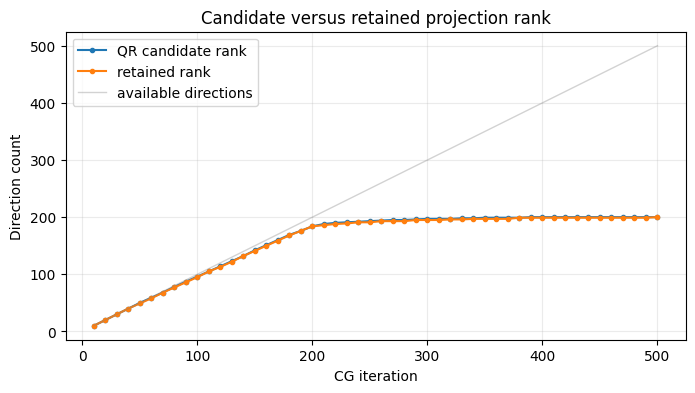

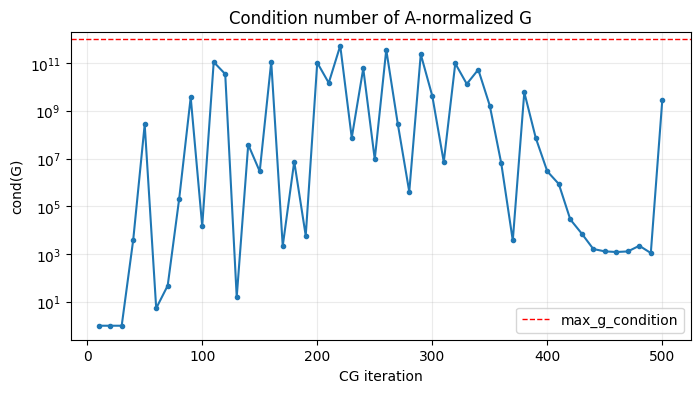

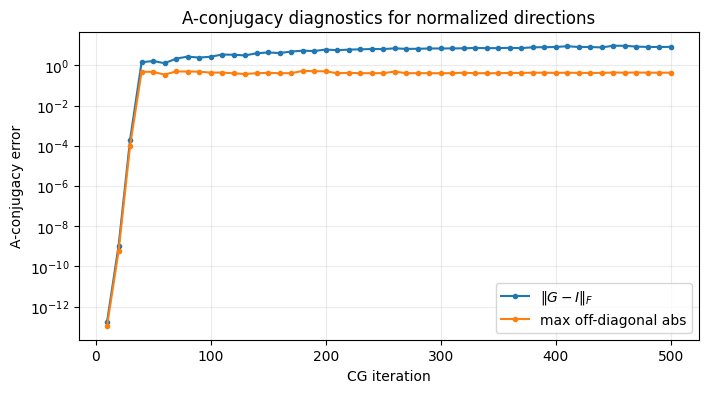

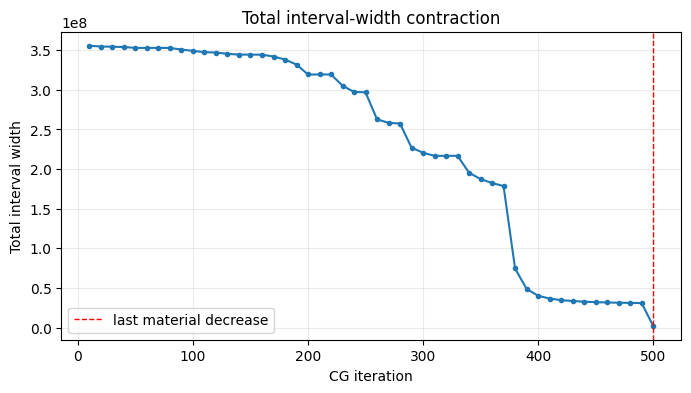

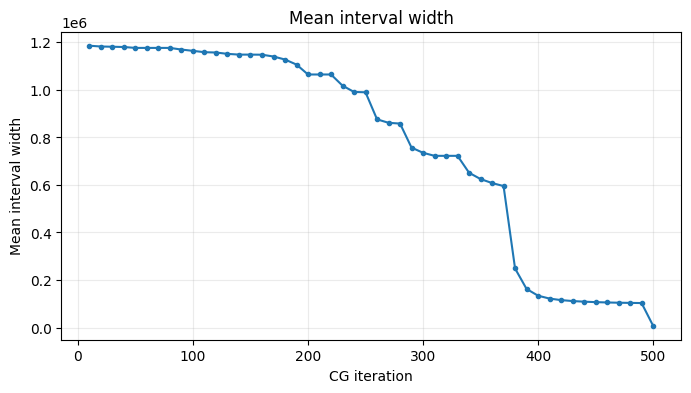

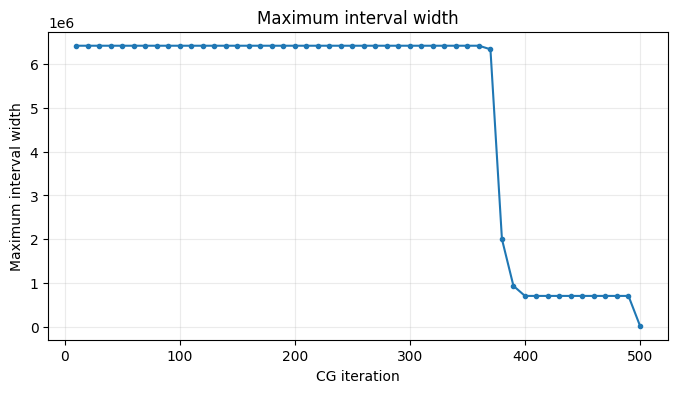

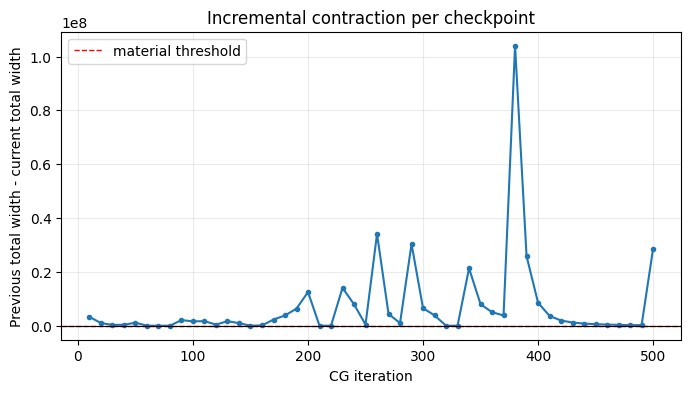

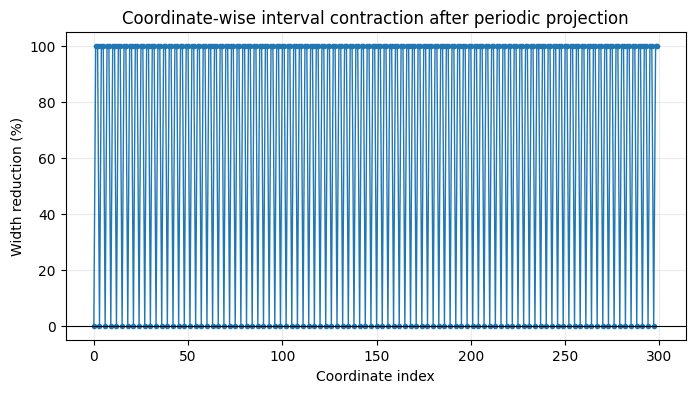

mean contraction %: 66.66447572080861
median contraction %: 99.99427268793916
min contraction %: -2.220446049250313e-14
max contraction %: 99.99999958926351
coordinates contracted: 200
all intervals contain x_star: True
x_star contained in every reported preconditioned interval: True

Validation checks:
max |retained A-norm - 1|: 7.105427e-15
max |diag(G) - 1|: 2.664535e-15
||G - G.T||_inf: 4.639786e-11
max selected constraint residual at x_hat: 1.989924e-06
no interval wider than previous checkpoint: True
final interval contained in initial interval: True

Diagnostic summary:
final CG iteration: 500
total available directions: 500
QR candidate rank: 200
retained rank: 200
normalized cond(G): 2.989023e+09
||G-I||_F: 8.282022e+00
last retained-rank increase iteration: 500
last total-width decrease > 1e-10 relative threshold: 500
final total width: 2.325689e+06
final mean width: 7.752296e+03
final maximum width: 3.153157e+04
plateau coincidence: neither


## Observed diagnostic answer

With A-normalized directions, the final checkpoint at CG iteration 500 retained 200 directions out of a QR candidate rank of 200 and 500 recorded directions. The normalized Gram condition number was 2.989023e+09, with ||G-I||_F = 8.282022e+00.

The retained rank last increased at iteration 500, while the total interval width last decreased by more than the 1e-10 relative threshold at iteration 500. The final total, mean, and maximum preconditioned widths were 2.325689e+06, 7.752296e+03, and 3.153157e+04.

Based on these diagnostics, the contraction plateau coincides with neither. This reports the observed behavior; it does not assume the plateau is fixed.


In [7]:
initial_width = u0 - ell0
final_width = u_x - ell_x
initial_width_y = u_hat - ell_hat
width_history_y = contraction_run["u_history"] - contraction_run["ell_history"]
iteration_history = contraction_run["iterations"]
material_width_threshold = 1e-10 * float(np.sum(initial_width_y))

with np.errstate(divide="ignore", invalid="ignore"):
    shrinkage_history_pct = 100.0 * (1.0 - width_history_y / initial_width_y[None, :])
    contraction_pct = 100.0 * (1.0 - final_width / initial_width)

contains_x_star = np.logical_and(x_star >= ell_x, x_star <= u_x)
y_star = scale * x_star
contains_y_star_history = np.logical_and(
    y_star[None, :] >= contraction_run["ell_history"],
    y_star[None, :] <= contraction_run["u_history"],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(diagnostics_df["iteration"], diagnostics_df["qr_rank"], marker="o", markersize=3, label="QR candidate rank")
ax.plot(diagnostics_df["iteration"], diagnostics_df["retained_rank"], marker="o", markersize=3, label="retained rank")
ax.plot(
    diagnostics_df["iteration"],
    diagnostics_df["available_direction_count"],
    color="gray",
    alpha=0.35,
    linewidth=1,
    label="available directions",
)
ax.set_xlabel("CG iteration")
ax.set_ylabel("Direction count")
ax.set_title("Candidate versus retained projection rank")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(diagnostics_df["iteration"], diagnostics_df["g_condition"], marker="o", markersize=3)
ax.axhline(projection_max_g_condition, color="red", linestyle="--", linewidth=1, label="max_g_condition")
ax.set_xlabel("CG iteration")
ax.set_ylabel("cond(G)")
ax.set_title("Condition number of A-normalized G")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(diagnostics_df["iteration"], diagnostics_df["g_identity_fro"], marker="o", markersize=3, label=r"$\|G-I\|_F$")
ax.semilogy(
    diagnostics_df["iteration"],
    np.maximum(diagnostics_df["g_max_offdiag_abs"], np.finfo(float).tiny),
    marker="o",
    markersize=3,
    label="max off-diagonal abs",
)
ax.set_xlabel("CG iteration")
ax.set_ylabel("A-conjugacy error")
ax.set_title("A-conjugacy diagnostics for normalized directions")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()

last_material_decrease_iteration = np.nan
material_decreases = diagnostics_df.loc[
    diagnostics_df["width_reduction"] > material_width_threshold,
    "iteration",
]
if len(material_decreases):
    last_material_decrease_iteration = int(material_decreases.iloc[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(diagnostics_df["iteration"], diagnostics_df["total_width"], marker="o", markersize=3)
if np.isfinite(last_material_decrease_iteration):
    ax.axvline(last_material_decrease_iteration, color="red", linestyle="--", linewidth=1, label="last material decrease")
ax.set_xlabel("CG iteration")
ax.set_ylabel("Total interval width")
ax.set_title("Total interval-width contraction")
ax.grid(alpha=0.25)
if np.isfinite(last_material_decrease_iteration):
    ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(diagnostics_df["iteration"], diagnostics_df["current_mean_width"], marker="o", markersize=3)
ax.set_xlabel("CG iteration")
ax.set_ylabel("Mean interval width")
ax.set_title("Mean interval width")
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(diagnostics_df["iteration"], diagnostics_df["current_max_width"], marker="o", markersize=3)
ax.set_xlabel("CG iteration")
ax.set_ylabel("Maximum interval width")
ax.set_title("Maximum interval width")
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(diagnostics_df["iteration"], diagnostics_df["width_reduction"], marker="o", markersize=3)
ax.axhline(material_width_threshold, color="red", linestyle="--", linewidth=1, label="material threshold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("CG iteration")
ax.set_ylabel("Previous total width - current total width")
ax.set_title("Incremental contraction per checkpoint")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(contraction_pct, marker="o", markersize=3, linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coordinate index")
ax.set_ylabel("Width reduction (%)")
ax.set_title("Coordinate-wise interval contraction after periodic projection")
ax.grid(alpha=0.25)
plt.show()

final_width_y = u_y - ell_y
initial_total_width_y = float(np.sum(initial_width_y))
final_total_width_y = float(np.sum(final_width_y))
final_mean_width_y = float(np.mean(final_width_y))
final_max_width_y = float(np.max(final_width_y))

rank_increase_iterations = diagnostics_df.loc[
    diagnostics_df["retained_rank"].diff().fillna(diagnostics_df["retained_rank"]) > 0,
    "iteration",
]
last_rank_increase_iteration = int(rank_increase_iterations.iloc[-1]) if len(rank_increase_iterations) else np.nan
final_iteration = int(diagnostics_df["iteration"].iloc[-1])
condition_cap_active = bool(diagnostics_df["g_condition"].iloc[-1] >= 0.99 * projection_max_g_condition)
rank_stagnated_at_plateau = bool(
    np.isfinite(last_rank_increase_iteration)
    and np.isfinite(last_material_decrease_iteration)
    and last_rank_increase_iteration <= last_material_decrease_iteration < final_iteration
)
condition_cap_at_plateau = bool(
    condition_cap_active
    and np.isfinite(last_material_decrease_iteration)
    and last_material_decrease_iteration < final_iteration
)
if condition_cap_at_plateau:
    plateau_classification = "condition-number cap"
elif rank_stagnated_at_plateau:
    plateau_classification = "rank stagnation"
else:
    plateau_classification = "neither"

print("mean contraction %:", np.nanmean(contraction_pct))
print("median contraction %:", np.nanmedian(contraction_pct))
print("min contraction %:", np.nanmin(contraction_pct))
print("max contraction %:", np.nanmax(contraction_pct))
print("coordinates contracted:", int(np.sum(final_width < initial_width)))
print("all intervals contain x_star:", bool(np.all(contains_x_star)))
print("x_star contained in every reported preconditioned interval:", bool(np.all(contains_y_star_history)))
if not np.all(contains_x_star):
    print("first coordinates missing x_star:", np.flatnonzero(~contains_x_star)[:10])

print("\nValidation checks:")
print("max |retained A-norm - 1|:", f"{projection_result['a_norm_unit_max_error']:.6e}")
print("max |diag(G) - 1|:", f"{projection_result['g_diag_max_abs_error']:.6e}")
print("||G - G.T||_inf:", f"{projection_result['g_symmetry_error']:.6e}")
print("max selected constraint residual at x_hat:", f"{projection_result['max_constraint_residual_x_hat']:.6e}")
print("no interval wider than previous checkpoint:", bool(np.all(np.diff(width_history_y, axis=0) <= 100.0 * np.finfo(float).eps * max(1.0, float(np.max(initial_width_y))))))
print("final interval contained in initial interval:", bool(np.all(ell_y >= ell_hat - 1e-12) and np.all(u_y <= u_hat + 1e-12)))

print("\nDiagnostic summary:")
print("final CG iteration:", final_iteration)
print("total available directions:", int(projection_result["available_direction_count"]))
print("QR candidate rank:", int(projection_result["qr_rank"]))
print("retained rank:", int(projection_result["retained_rank"]))
print("normalized cond(G):", f"{projection_result['g_condition']:.6e}")
print("||G-I||_F:", f"{projection_result['g_identity_fro']:.6e}")
print("last retained-rank increase iteration:", last_rank_increase_iteration)
print("last total-width decrease > 1e-10 relative threshold:", last_material_decrease_iteration)
print("final total width:", f"{final_total_width_y:.6e}")
print("final mean width:", f"{final_mean_width_y:.6e}")
print("final maximum width:", f"{final_max_width_y:.6e}")
print("plateau coincidence:", plateau_classification)

observed_answer_markdown = f"""## Observed diagnostic answer

With A-normalized directions, the final checkpoint at CG iteration {final_iteration} retained {int(projection_result['retained_rank'])} directions out of a QR candidate rank of {int(projection_result['qr_rank'])} and {int(projection_result['available_direction_count'])} recorded directions. The normalized Gram condition number was {projection_result['g_condition']:.6e}, with ||G-I||_F = {projection_result['g_identity_fro']:.6e}.

The retained rank last increased at iteration {last_rank_increase_iteration}, while the total interval width last decreased by more than the 1e-10 relative threshold at iteration {last_material_decrease_iteration}. The final total, mean, and maximum preconditioned widths were {final_total_width_y:.6e}, {final_mean_width_y:.6e}, and {final_max_width_y:.6e}.

Based on these diagnostics, the contraction plateau coincides with {plateau_classification}. This reports the observed behavior; it does not assume the plateau is fixed.
"""
display(Markdown(observed_answer_markdown))


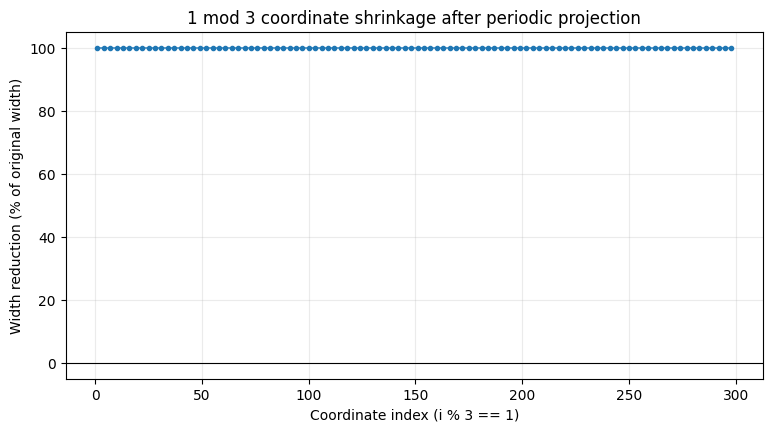

1 mod 3 coordinates: 100
mean 1 mod 3 contraction %: 99.9970259581794
median 1 mod 3 contraction %: 99.99914613379187
min 1 mod 3 contraction %: 99.9887272780929
max 1 mod 3 contraction %: 99.99999958926351


In [8]:
mod3_indices = np.arange(len(initial_width))
mod3_indices = mod3_indices[mod3_indices % 3 == 1]

mod3_shrinkage_pct = contraction_pct[mod3_indices]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    mod3_indices,
    mod3_shrinkage_pct,
    marker="o",
    markersize=3,
    linewidth=1,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coordinate index (i % 3 == 1)")
ax.set_ylabel("Width reduction (% of original width)")
ax.set_title("1 mod 3 coordinate shrinkage after periodic projection")
ax.grid(alpha=0.25)
plt.show()

print("1 mod 3 coordinates:", len(mod3_indices))
print("mean 1 mod 3 contraction %:", np.nanmean(mod3_shrinkage_pct))
print("median 1 mod 3 contraction %:", np.nanmedian(mod3_shrinkage_pct))
print("min 1 mod 3 contraction %:", np.nanmin(mod3_shrinkage_pct))
print("max 1 mod 3 contraction %:", np.nanmax(mod3_shrinkage_pct))


def display_shrinkage_animation(shrinkage_history, iterations, coordinate_indices, title):
    coordinate_indices = np.asarray(coordinate_indices)
    frame_data = shrinkage_history[:, coordinate_indices]
    finite_values = frame_data[np.isfinite(frame_data)]
    y_upper = 1.0 if finite_values.size == 0 else min(100.0, max(1.0, float(np.nanmax(finite_values)) * 1.05))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    line, = ax.plot(
        coordinate_indices,
        np.nan_to_num(frame_data[0], nan=0.0, posinf=100.0, neginf=0.0),
        marker="o" if len(coordinate_indices) <= 120 else None,
        markersize=3,
        linewidth=1,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    iteration_label = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")
    ax.set_xlim(coordinate_indices.min(), coordinate_indices.max())
    ax.set_ylim(0, y_upper)
    ax.set_xlabel("Coordinate index")
    ax.set_ylabel("Width reduction (% of original width)")
    ax.set_title(title)
    ax.grid(alpha=0.25)

    def update(frame):
        y = np.nan_to_num(frame_data[frame], nan=0.0, posinf=100.0, neginf=0.0)
        line.set_ydata(y)
        iteration_label.set_text(f"iteration {int(iterations[frame])}")
        return line, iteration_label

    animation = FuncAnimation(
        fig,
        update,
        frames=len(iterations),
        interval=180,
        blit=False,
        repeat_delay=1000,
    )
    display(HTML(animation.to_jshtml(fps=5, default_mode="loop")))
    plt.close(fig)
    return animation


all_coordinate_animation = display_shrinkage_animation(
    shrinkage_history=shrinkage_history_pct,
    iterations=iteration_history,
    coordinate_indices=np.arange(len(initial_width)),
    title="All-coordinate shrinkage over periodic contractions",
)

mod1_coordinate_animation = display_shrinkage_animation(
    shrinkage_history=shrinkage_history_pct,
    iterations=iteration_history,
    coordinate_indices=mod3_indices,
    title="1 mod 3 coordinate shrinkage over periodic contractions",
)


## Observed diagnostic answer

With A-normalized directions, the final checkpoint at CG iteration 500 retained 200 directions out of a QR candidate rank of 200 and 500 recorded directions. The normalized Gram condition number was 2.989023e+09, with ||G-I||_F = 8.282022e+00.

The raw-direction comparison retained only 74 directions at the same final checkpoint, with cond(G) = 9.993935e+11 and final total width 2.373219e+08. On the same indices selected by the A-normalized method, the raw Gram condition number was 1.244353e+15, showing that raw scaling would trip the condition filter even for useful directions.

The retained rank last increased at iteration 500, and the total interval width also last decreased by more than the 1e-10 relative threshold at iteration 500. The final total, mean, and maximum preconditioned widths were 2.325691e+06, 7.752304e+03, and 3.153157e+04.

Based on these diagnostics, the observed plateau does not coincide with retained-rank stagnation or the normalized condition-number cap. The earlier raw-direction behavior is consistent with premature rejection caused by unnormalized direction scaling, but this summary reports the observed diagnostics rather than claiming the projection enclosure has no remaining inherent limit.
